## U-FISH Finetuning Preprocessing Visualizer (Strict U-FISH + YOLO Adaptation)

This notebook explains and visualizes **exactly** what is fed to U-FISH during finetuning on your dataset.

#### What this notebook will show
1. What official U-FISH expects as input and target.
2. How YOLO bounding boxes are converted to point annotations for U-FISH.
3. How we build the official U-FISH density target (Gaussian with `sigma=1`).
4. Comparison of preprocessing with and without DAPI subtraction.
5. Final tensors fed to model: input and target shapes/ranges.

#### Dataset
- Root: `/home/sukrit/saaransh/fish_project_sota_work/Model_B/Gene-Dataset-5Fold-Merged`
- Folds: `fold-1` ... `fold-5`
- Labels: YOLO format `[class cx cy w h]` (normalized).

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from scipy import ndimage as ndi

from ufish.utils.img import scale_image

# Paths
DATA_ROOT = "/home/sukrit/saaransh/fish_project_sota_work/Model_B/Gene-Dataset-5Fold-Merged"

print("Dataset root:", DATA_ROOT)
for k in range(1, 6):
    n_img = len(glob.glob(os.path.join(DATA_ROOT, f"fold-{k}", "images", "*.jpg"))) + \
            len(glob.glob(os.path.join(DATA_ROOT, f"fold-{k}", "images", "*.png")))
    print(f"fold-{k}: {n_img} images")

Dataset root: /home/sukrit/saaransh/fish_project_sota_work/Model_B/Gene-Dataset-5Fold-Merged
fold-1: 868 images
fold-2: 855 images
fold-3: 853 images
fold-4: 856 images
fold-5: 841 images


## What U-FISH strictly expects

### Input (official)
- **Single-channel grayscale image** (`H×W`) per sample.
- Intensities are processed by `ufish.utils.img.scale_image(...)` to `float32` in **[0, 255]**.
- U-FISH model input tensor shape is `(B, 1, H, W)`.

### Target (official)
- Point annotations (spot centers), **not bounding boxes**.
- Build binary mask (1 at each point), then apply Gaussian filter with **`sigma=1`**.
- Peak-normalize the filtered map using official logic.
- Target tensor shape is `(B, 1, H, W)`.

### Why YOLO needs adaptation
Your labels are YOLO boxes `[class, cx, cy, w, h]`. For U-FISH training, we convert each box to one point at `(cx, cy)`.

In [2]:
import inspect
from ufish.data import FISHSpotsDataset

print("=== U-FISH source checks (official package) ===\n")

print("1) scale_image() source (input preprocessing):")
print(inspect.getsource(scale_image))

print("\n2) FISHSpotsDataset.gaussian_filter() source (target generation):")
print(inspect.getsource(FISHSpotsDataset.gaussian_filter))

print("\n3) FISHSpotsDataset.coords_to_target() source (binary mask -> target):")
print(inspect.getsource(FISHSpotsDataset.coords_to_target))

=== U-FISH source checks (official package) ===

1) scale_image() source (input preprocessing):
def scale_image(
        img: np.ndarray,
        big_quantile: float = 0.9999,
        ) -> np.ndarray:
    """Scale an image to 0-255.
    If the image has outlier values,
    the image will be scaled to 0-big_value.

    Args:
        img: Image to scale.
        big_quantile: Quantile to calculate the big value.
    """
    dtype = img.dtype
    img = img.astype(np.float32)
    if dtype is not np.uint8:
        big_value = np.quantile(img, big_quantile)
        if img_has_outlier(img, big_value):
            if warning:
                from .log import logger
                logger.warning(
                    'Image has outlier values. ')
            in_range = (0, big_value)
        else:
            in_range = 'image'
        img = rescale_intensity(
            img,
            in_range=in_range,
            out_range=(0, 255),
        )
    return img


2) FISHSpotsDataset.gaussian_

In [3]:
def get_probe_channel(filename: str) -> int:
    name = os.path.basename(filename).upper()
    if "ORANGE" in name:
        return 0
    if "FITC" in name or "GREEN" in name:
        return 1
    if "AQUA" in name:
        return 2
    return 0


def parse_yolo_boxes(label_path: str, img_w: int, img_h: int):
    boxes = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            cx = float(parts[1]) * img_w
            cy = float(parts[2]) * img_h
            bw = float(parts[3]) * img_w
            bh = float(parts[4]) * img_h
            boxes.append((cls, cx, cy, bw, bh))
    return boxes


def yolo_boxes_to_points(boxes):
    # U-FISH uses point annotations only
    return [(cy, cx) for (_, cx, cy, _, _) in boxes]


def official_density_from_points(points, h, w, sigma=1.0):
    """Official U-FISH target logic: binary points -> gaussian_filter(sigma=1) -> peak normalization."""
    mask = np.zeros((h, w), dtype=np.float32)
    if len(points) == 0:
        return mask, mask

    valid_coords = []
    for r, c in points:
        ri = int(round(r))
        ci = int(round(c))
        ri = max(0, min(ri, h - 1))
        ci = max(0, min(ci, w - 1))
        mask[ri, ci] = 1.0
        valid_coords.append((ri, ci))

    den = ndi.gaussian_filter(mask, sigma=sigma)
    peak_vals = np.array([den[r, c] for r, c in valid_coords])
    if len(peak_vals) > 0 and peak_vals.min() > 0:
        den = den / peak_vals.min()

    return mask, den


def preprocess_probe(img_rgb, subtract_dapi=False):
    """Single-channel probe extraction + official scale_image to [0,255]."""
    img_f = img_rgb.astype(np.float32) / 255.0
    probe_ch = get_probe_channel(sample_img_name)

    probe = img_f[:, :, probe_ch]
    if subtract_dapi and probe_ch != 2:
        dapi = img_f[:, :, 2]
        probe = np.clip(probe - dapi, 0.0, 1.0)

    probe_255 = (probe * 255.0).astype(np.float32)
    scaled = scale_image(probe_255, warning=False)
    return probe_ch, probe, scaled


# pick one sample from fold-1 for demonstration
fold_img_dir = os.path.join(DATA_ROOT, "fold-1", "images")
fold_lbl_dir = os.path.join(DATA_ROOT, "fold-1", "labels")

sample_img_path = sorted(glob.glob(os.path.join(fold_img_dir, "*.jpg")) + glob.glob(os.path.join(fold_img_dir, "*.png")))[0]
sample_img_name = os.path.basename(sample_img_path)
sample_lbl_path = os.path.join(fold_lbl_dir, os.path.splitext(sample_img_name)[0] + ".txt")

img_rgb = np.array(Image.open(sample_img_path).convert("RGB"), dtype=np.uint8)
H, W = img_rgb.shape[:2]
boxes = parse_yolo_boxes(sample_lbl_path, W, H)
points = yolo_boxes_to_points(boxes)

print("Sample image:", sample_img_name)
print("Shape:", img_rgb.shape)
print("YOLO boxes:", len(boxes))
print("Converted points:", len(points))

Sample image: AL_102_22_FITC_cell1_png.rf.8c3505fbe59d71c348bed9fbca823977.jpg
Shape: (512, 512, 3)
YOLO boxes: 4
Converted points: 4


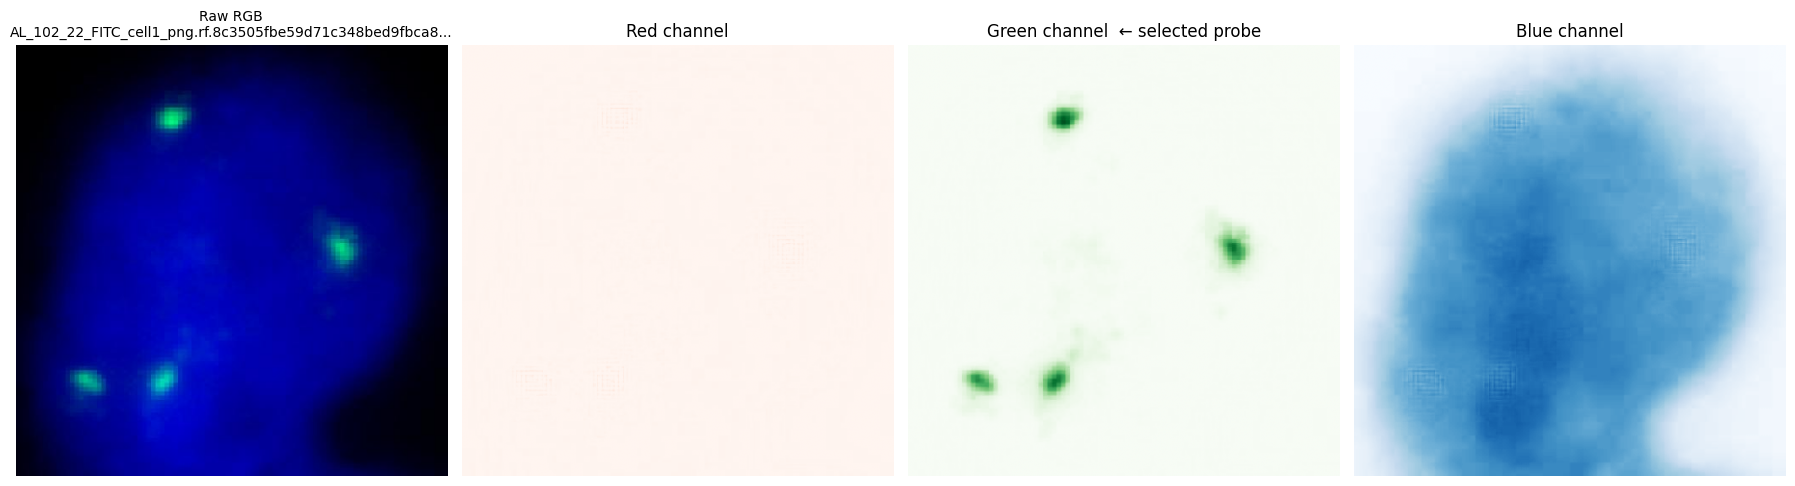

Probe channel selected from filename: 1 (Green)


In [4]:
# Visualize raw RGB and class-specific channel used for this sample
probe_ch = get_probe_channel(sample_img_name)
ch_names = ["Red", "Green", "Blue"]
cmaps = ["Reds", "Greens", "Blues"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
axes[0].imshow(img_rgb)
axes[0].set_title(f"Raw RGB\n{sample_img_name[:55]}...", fontsize=10)
axes[0].axis("off")

for i in range(3):
    axes[i+1].imshow(img_rgb[:, :, i], cmap=cmaps[i], vmin=0, vmax=255)
    mark = "  ← selected probe" if i == probe_ch else ""
    axes[i+1].set_title(f"{ch_names[i]} channel{mark}")
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

print(f"Probe channel selected from filename: {probe_ch} ({ch_names[probe_ch]})")

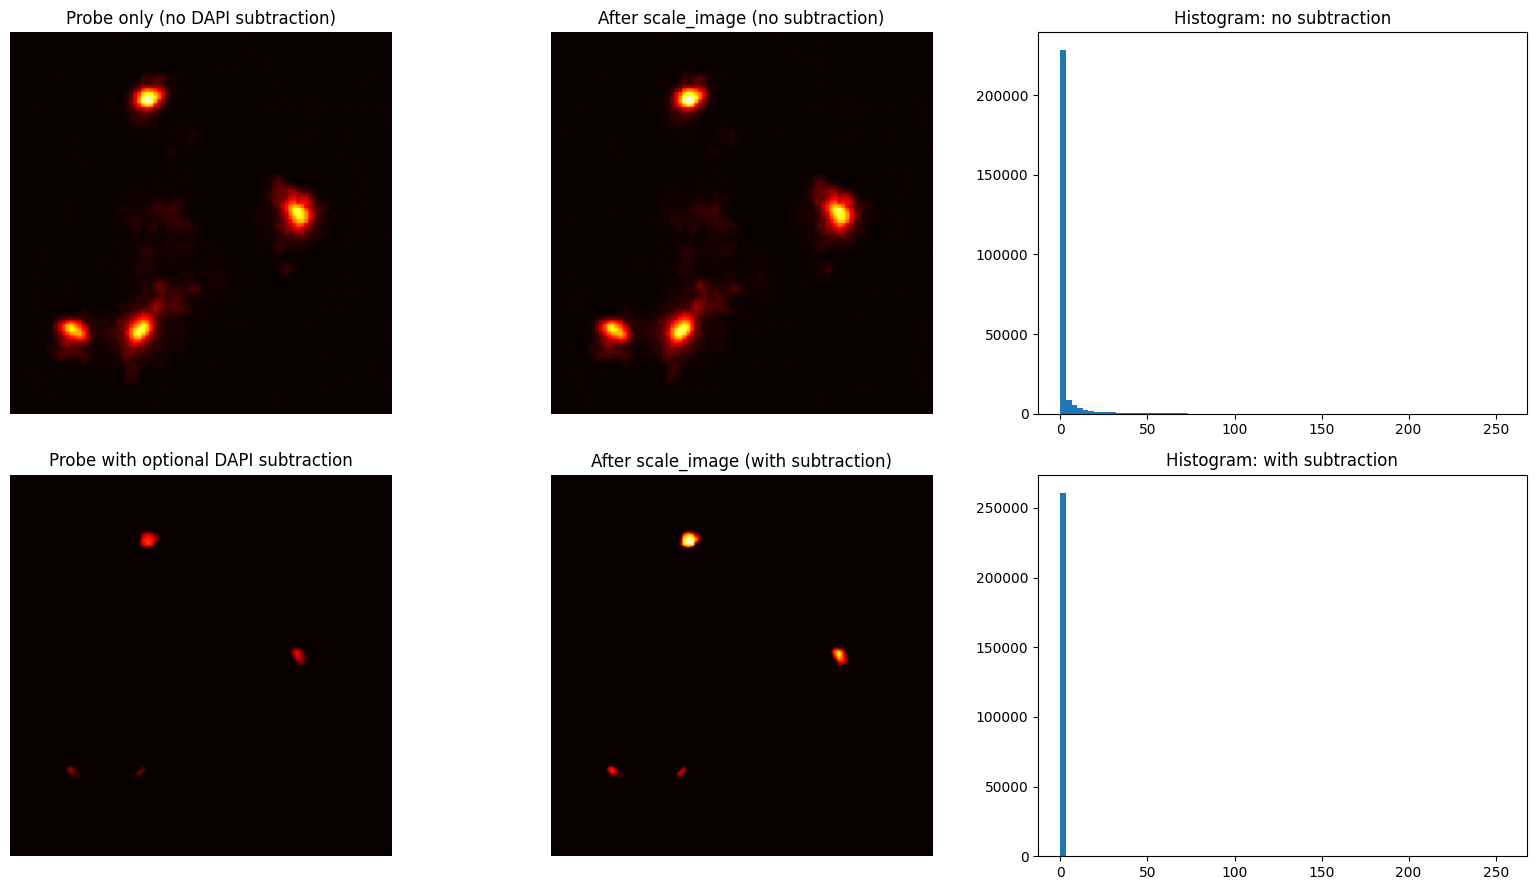

Official U-FISH requirement: single-channel image after scale_image().
DAPI subtraction is NOT in official U-FISH; here it is an optional adaptation for RGB composite datasets.


In [5]:
# Compare preprocessing WITHOUT and WITH optional DAPI subtraction
probe_ch0, probe_raw, scaled_no_sub = preprocess_probe(img_rgb, subtract_dapi=False)
probe_ch1, probe_sub, scaled_with_sub = preprocess_probe(img_rgb, subtract_dapi=True)

assert probe_ch0 == probe_ch1

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].imshow(probe_raw, cmap="hot", vmin=0, vmax=1)
axes[0, 0].set_title("Probe only (no DAPI subtraction)")
axes[0, 0].axis("off")

axes[0, 1].imshow(scaled_no_sub, cmap="hot")
axes[0, 1].set_title("After scale_image (no subtraction)")
axes[0, 1].axis("off")

axes[0, 2].hist(scaled_no_sub.flatten(), bins=80)
axes[0, 2].set_title("Histogram: no subtraction")

axes[1, 0].imshow(probe_sub, cmap="hot", vmin=0, vmax=1)
axes[1, 0].set_title("Probe with optional DAPI subtraction")
axes[1, 0].axis("off")

axes[1, 1].imshow(scaled_with_sub, cmap="hot")
axes[1, 1].set_title("After scale_image (with subtraction)")
axes[1, 1].axis("off")

axes[1, 2].hist(scaled_with_sub.flatten(), bins=80)
axes[1, 2].set_title("Histogram: with subtraction")

plt.tight_layout()
plt.show()

print("Official U-FISH requirement: single-channel image after scale_image().")
print("DAPI subtraction is NOT in official U-FISH; here it is an optional adaptation for RGB composite datasets.")

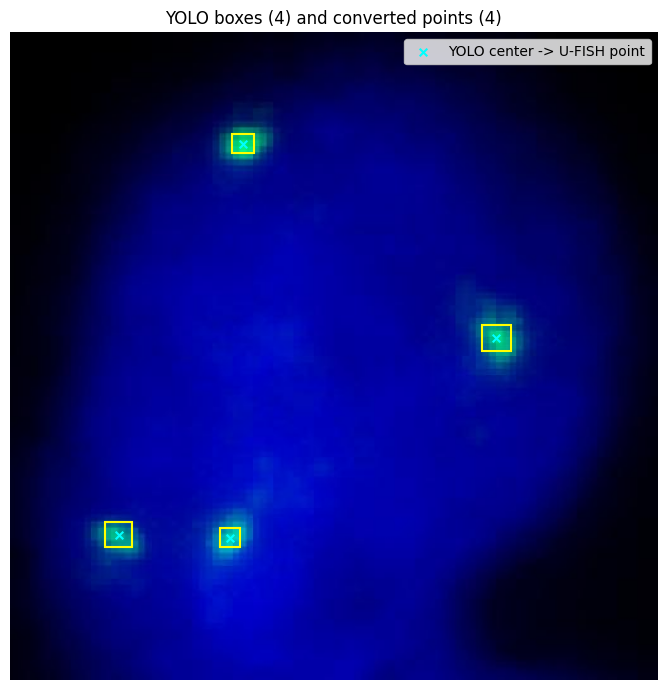

In [6]:
# Visualize YOLO boxes and converted point centers
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(img_rgb)

for cls, cx, cy, bw, bh in boxes:
    rect = patches.Rectangle((cx - bw/2, cy - bh/2), bw, bh,
                             linewidth=1.5, edgecolor='yellow', facecolor='none')
    ax.add_patch(rect)

if len(points) > 0:
    ys = [p[0] for p in points]
    xs = [p[1] for p in points]
    ax.scatter(xs, ys, c='cyan', s=30, marker='x', label='YOLO center -> U-FISH point')
    ax.legend(loc='upper right')

ax.set_title(f"YOLO boxes ({len(boxes)}) and converted points ({len(points)})")
ax.axis('off')
plt.tight_layout()
plt.show()

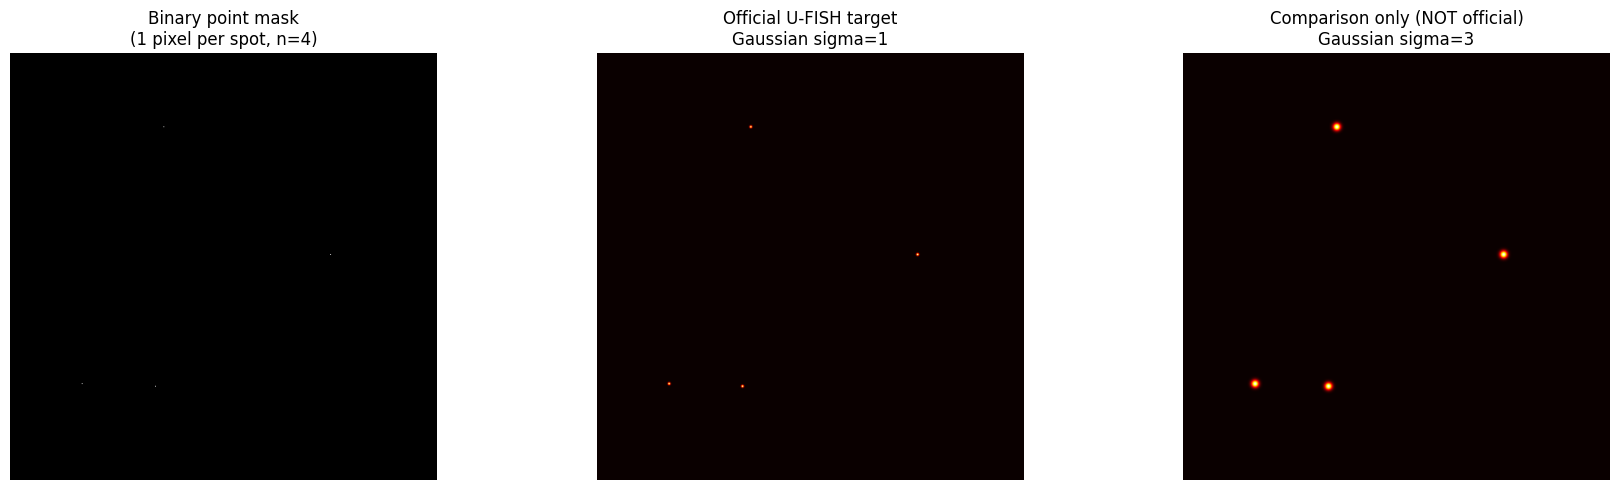

sigma=1 target range: [0.0000, 1.0000]
sigma=3 target range: [0.0000, 1.0000]
For strict U-FISH finetuning, always use sigma=1 for target generation.


In [7]:
# Build official U-FISH target maps from points
binary_mask, density_sigma1 = official_density_from_points(points, H, W, sigma=1.0)
_, density_sigma3 = official_density_from_points(points, H, W, sigma=3.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(binary_mask, cmap='gray')
axes[0].set_title(f"Binary point mask\n(1 pixel per spot, n={len(points)})")
axes[0].axis('off')

axes[1].imshow(density_sigma1, cmap='hot')
axes[1].set_title("Official U-FISH target\nGaussian sigma=1")
axes[1].axis('off')

axes[2].imshow(density_sigma3, cmap='hot')
axes[2].set_title("Comparison only (NOT official)\nGaussian sigma=3")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"sigma=1 target range: [{density_sigma1.min():.4f}, {density_sigma1.max():.4f}]")
print(f"sigma=3 target range: [{density_sigma3.min():.4f}, {density_sigma3.max():.4f}]")
print("For strict U-FISH finetuning, always use sigma=1 for target generation.")

Tensor shapes fed to model:
  Input strict (no DAPI sub): (1, 512, 512) range: (0.0, 255.0)
  Input adapt  (with DAPI):  (1, 512, 512) range: (0.0, 255.0)
  Target (official sigma=1): (1, 512, 512) range: (0.0, 1.0)


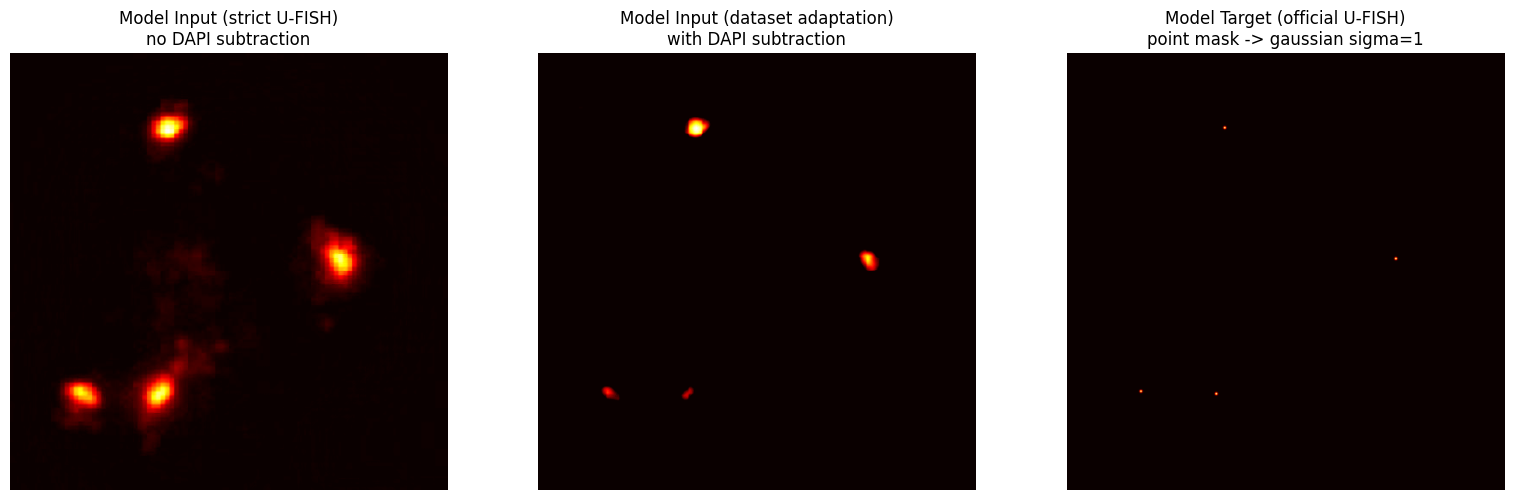

In [8]:
# Final tensors that are fed to U-FISH during finetuning
import torch

# Strict U-FISH input branch (no DAPI subtraction)
probe_ch, probe_clean, scaled_input_strict = preprocess_probe(img_rgb, subtract_dapi=False)

# Optional adaptation branch (with DAPI subtraction)
_, probe_adapt, scaled_input_adapt = preprocess_probe(img_rgb, subtract_dapi=True)

# Official target (same for both branches)
_, target_density = official_density_from_points(points, H, W, sigma=1.0)

x_strict = torch.from_numpy(scaled_input_strict[np.newaxis]).float()  # (1,H,W)
x_adapt = torch.from_numpy(scaled_input_adapt[np.newaxis]).float()    # (1,H,W)
y = torch.from_numpy(target_density[np.newaxis]).float()               # (1,H,W)

print("Tensor shapes fed to model:")
print("  Input strict (no DAPI sub):", tuple(x_strict.shape), "range:", (float(x_strict.min()), float(x_strict.max())))
print("  Input adapt  (with DAPI): ", tuple(x_adapt.shape), "range:", (float(x_adapt.min()), float(x_adapt.max())))
print("  Target (official sigma=1):", tuple(y.shape), "range:", (float(y.min()), float(y.max())))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(x_strict.squeeze().numpy(), cmap='hot')
axes[0].set_title("Model Input (strict U-FISH)\nno DAPI subtraction")
axes[0].axis('off')

axes[1].imshow(x_adapt.squeeze().numpy(), cmap='hot')
axes[1].set_title("Model Input (dataset adaptation)\nwith DAPI subtraction")
axes[1].axis('off')

axes[2].imshow(y.squeeze().numpy(), cmap='hot')
axes[2].set_title("Model Target (official U-FISH)\npoint mask -> gaussian sigma=1")
axes[2].axis('off')

plt.tight_layout()
plt.show()